In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score, auc, accuracy_score, f1_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv("data.csv")

# Limpieza de nombres de columnas (algunos vienen con tabs/espacios extra)
df.columns = [c.strip() for c in df.columns]

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [4]:
# Valores nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")
print("Filas duplicadas:", df.duplicated().sum())


Valores nulos por columna:
0 valores nulos en total
Filas duplicadas: 0


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [6]:
target_counts = df["Target"].value_counts()
target_pct = df["Target"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2))


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


/tmp/ipykernel_142/439653696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Target", order=target_counts.index,


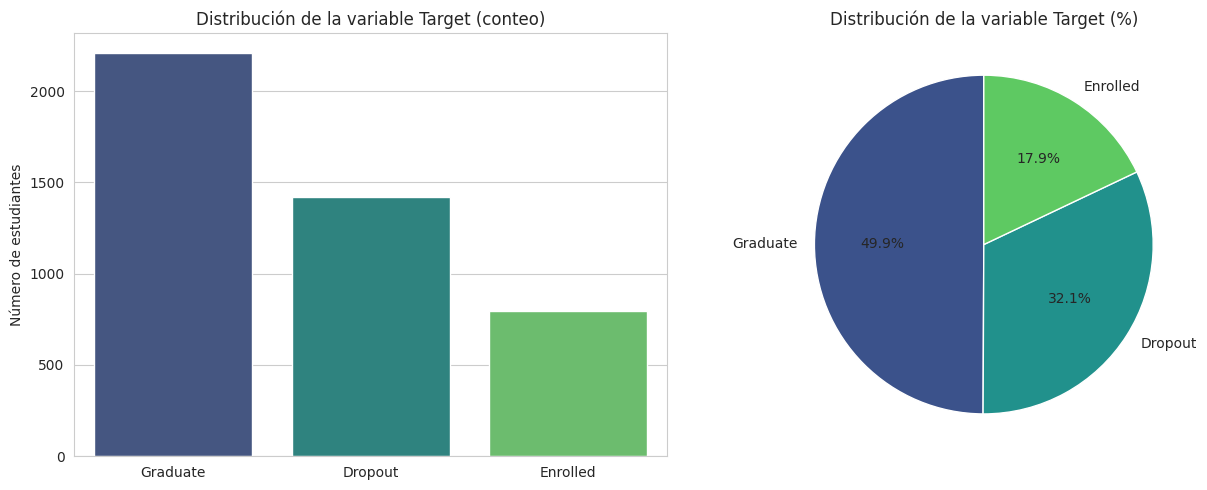

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="Target", order=target_counts.index,
              palette="viridis", ax=axes[0])
axes[0].set_title("Distribución de la variable Target (conteo)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Número de estudiantes")

axes[1].pie(target_pct.values, labels=target_pct.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", 3), startangle=90)
axes[1].set_title("Distribución de la variable Target (%)")

plt.tight_layout()
plt.show()


In [8]:
academic_vars = [
    "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Previous qualification",
    "Previous qualification (grade)", "Admission grade",
    "Educational special needs",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
]

demographic_vars = [
    "Marital status", "Nacionality", "Gender",
    "Age at enrollment", "International", "Displaced",
]

socioeconomic_vars = [
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    "Debtor", "Tuition fees up to date", "Scholarship holder",
    "Unemployment rate", "Inflation rate", "GDP",
]

print("Académicas:", len(academic_vars))
print("Demográficas:", len(demographic_vars))
print("Socioeconómicas:", len(socioeconomic_vars))
print("Total (sin Target):", len(academic_vars + demographic_vars + socioeconomic_vars))


Académicas: 20
Demográficas: 6
Socioeconómicas: 10
Total (sin Target): 36


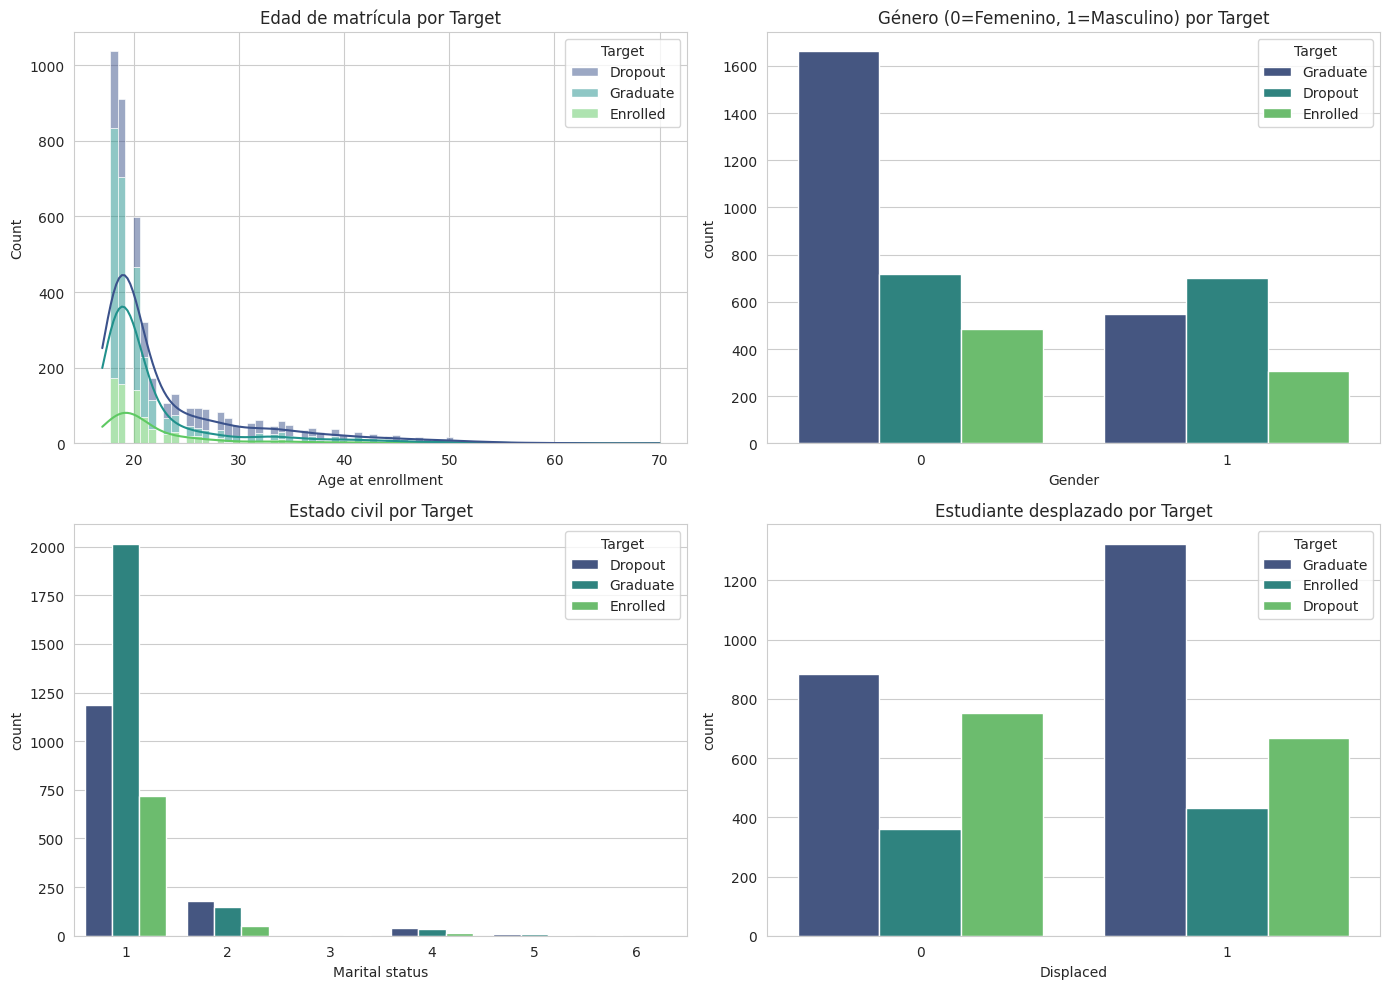

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x="Age at enrollment", hue="Target", kde=True,
             multiple="stack", palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Edad de matrícula por Target")

sns.countplot(data=df, x="Gender", hue="Target", palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Género (0=Femenino, 1=Masculino) por Target")

sns.countplot(data=df, x="Marital status", hue="Target", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Estado civil por Target")
axes[1, 0].tick_params(axis="x", rotation=0)

sns.countplot(data=df, x="Displaced", hue="Target", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Estudiante desplazado por Target")

plt.tight_layout()
plt.show()


/tmp/ipykernel_142/1990168866.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Unemployment rate", palette="magma", ax=axes[1, 1])


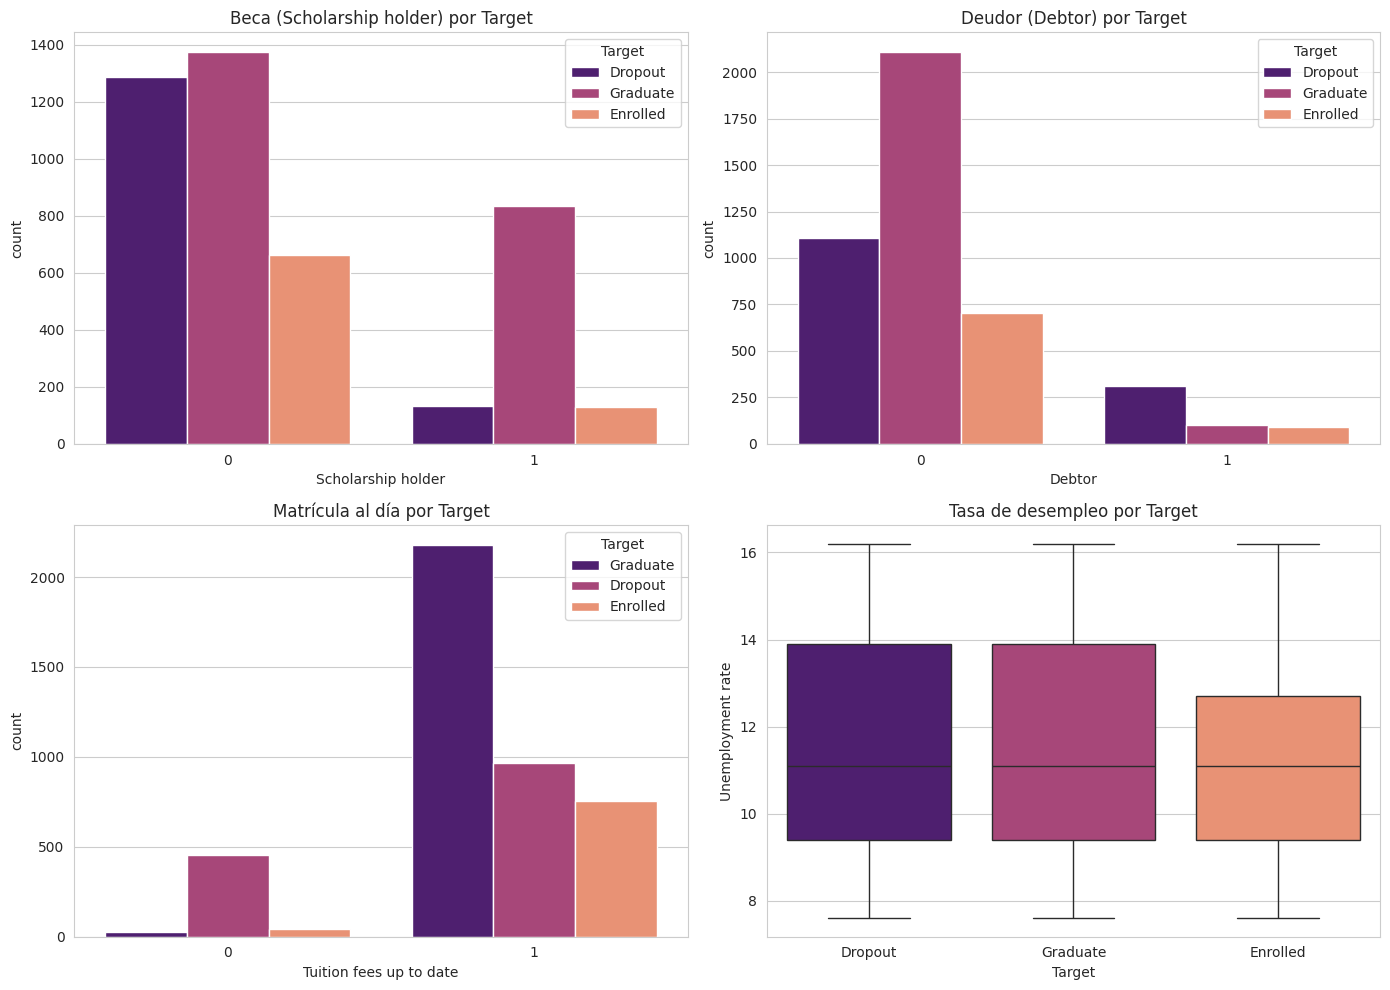

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Scholarship holder", hue="Target", palette="magma", ax=axes[0, 0])
axes[0, 0].set_title("Beca (Scholarship holder) por Target")

sns.countplot(data=df, x="Debtor", hue="Target", palette="magma", ax=axes[0, 1])
axes[0, 1].set_title("Deudor (Debtor) por Target")

sns.countplot(data=df, x="Tuition fees up to date", hue="Target", palette="magma", ax=axes[1, 0])
axes[1, 0].set_title("Matrícula al día por Target")

sns.boxplot(data=df, x="Target", y="Unemployment rate", palette="magma", ax=axes[1, 1])
axes[1, 1].set_title("Tasa de desempleo por Target")

plt.tight_layout()
plt.show()


/tmp/ipykernel_142/335557817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Admission grade", palette="crest", ax=axes[0, 0])
/tmp/ipykernel_142/335557817.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Curricular units 1st sem (grade)", palette="crest", ax=axes[0, 1])
/tmp/ipykernel_142/335557817.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)", palette="crest", ax=axes[1, 0])
/tmp/ipykernel_142/335557817.py:12: FutureWarnin

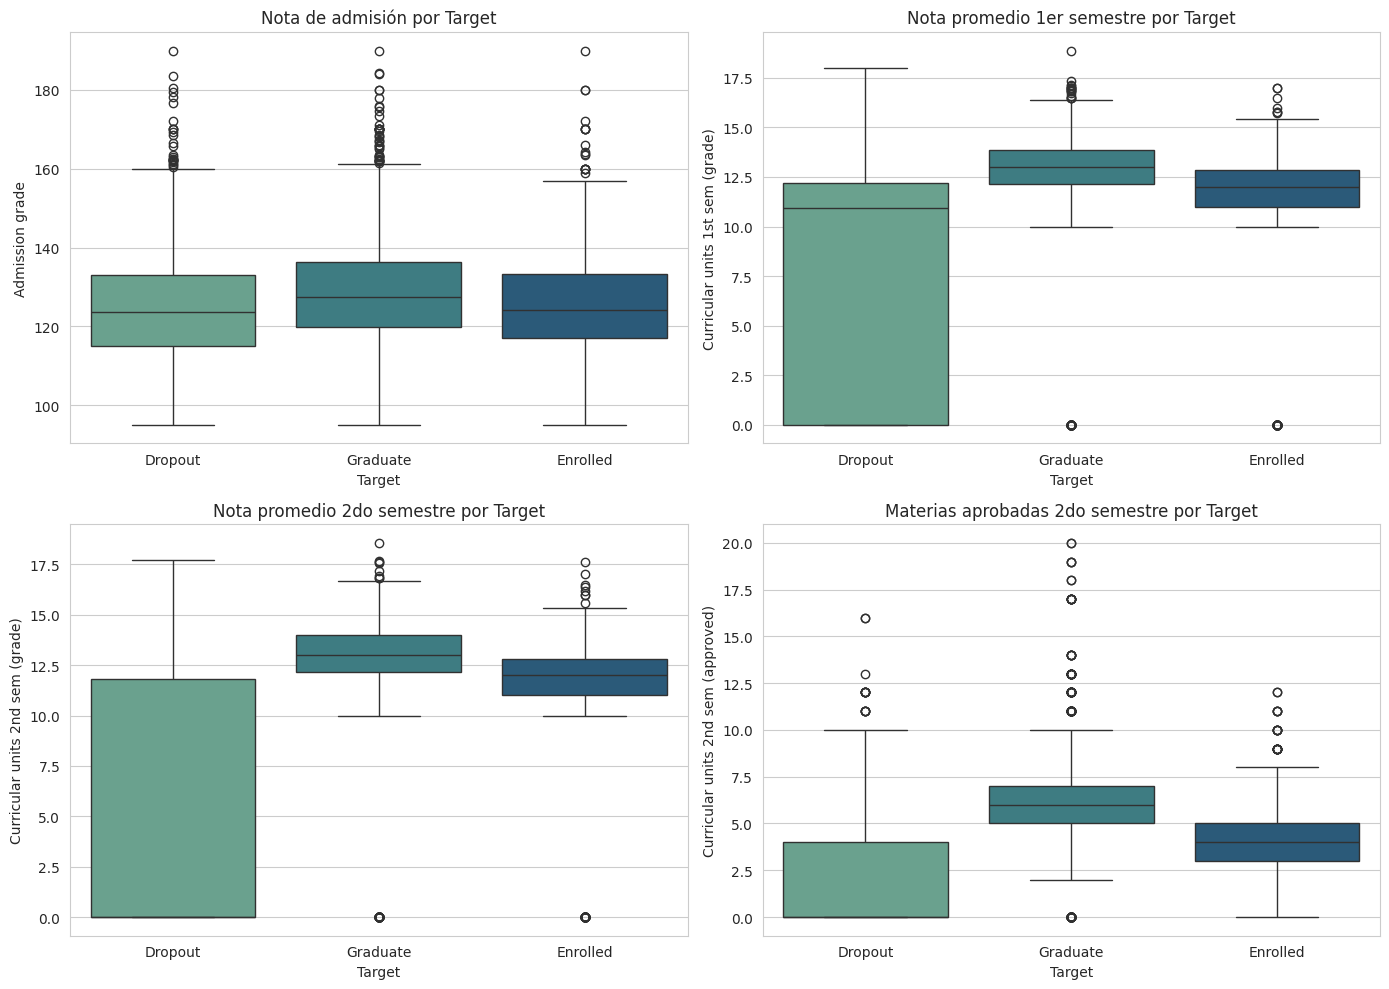

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x="Target", y="Admission grade", palette="crest", ax=axes[0, 0])
axes[0, 0].set_title("Nota de admisión por Target")

sns.boxplot(data=df, x="Target", y="Curricular units 1st sem (grade)", palette="crest", ax=axes[0, 1])
axes[0, 1].set_title("Nota promedio 1er semestre por Target")

sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)", palette="crest", ax=axes[1, 0])
axes[1, 0].set_title("Nota promedio 2do semestre por Target")

sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (approved)", palette="crest", ax=axes[1, 1])
axes[1, 1].set_title("Materias aprobadas 2do semestre por Target")

plt.tight_layout()
plt.show()


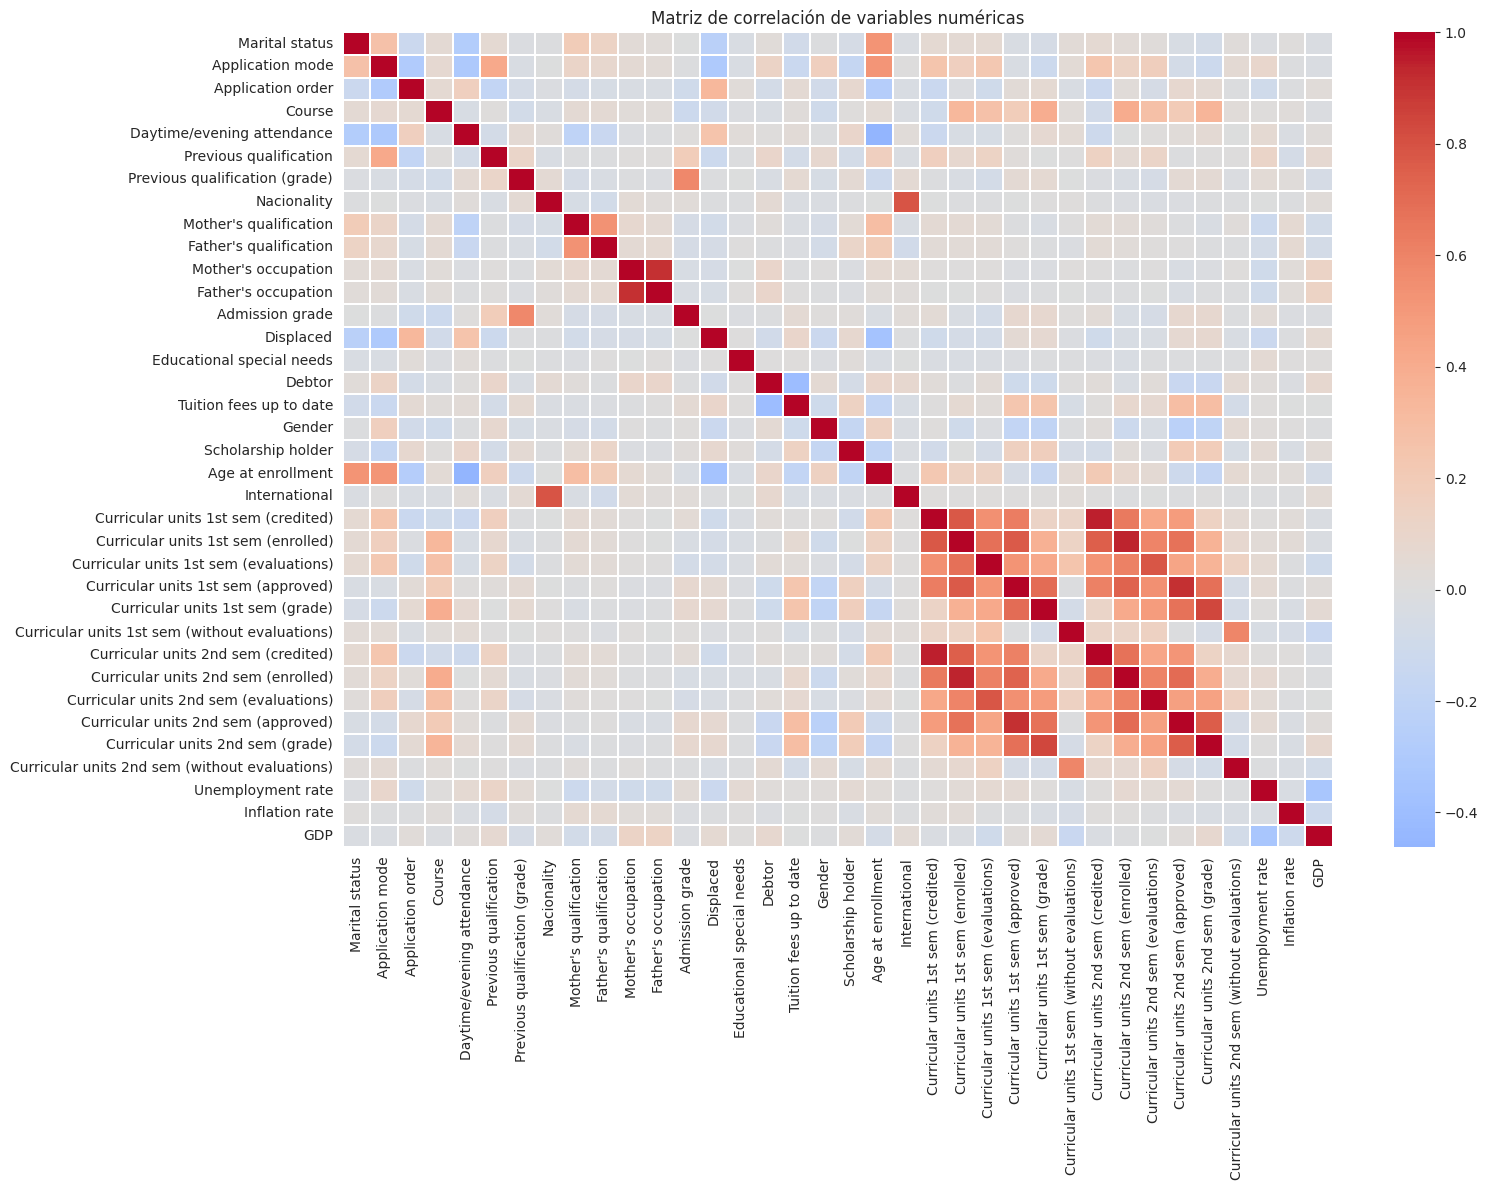

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(16, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


In [13]:
# Codificación de la variable objetivo
le = LabelEncoder()
df["Target_enc"] = le.fit_transform(df["Target"])
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [14]:
feature_cols = academic_vars + demographic_vars + socioeconomic_vars

X = df[feature_cols].copy()
y = df["Target_enc"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3318, 36)  Test: (1106, 36)


In [15]:
# Escalado (necesario especialmente para KNN, que se basa en distancias)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Mejor k encontrado: 11


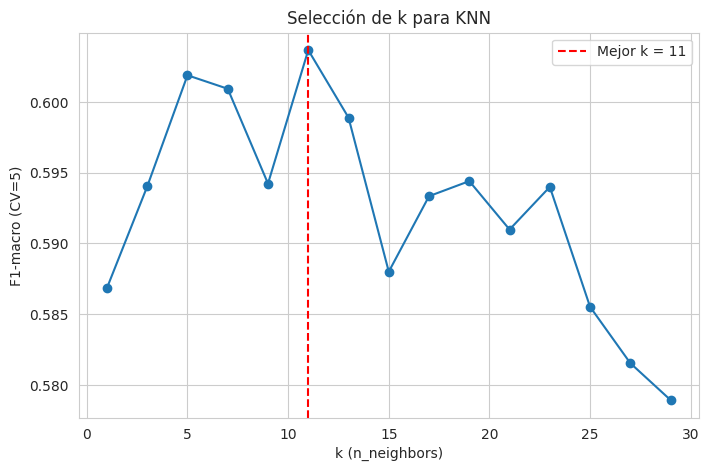

In [16]:
k_values = range(1, 31, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="f1_macro")
    cv_scores.append(scores.mean())

best_k = list(k_values)[int(np.argmax(cv_scores))]
print("Mejor k encontrado:", best_k)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), cv_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Mejor k = {best_k}")
plt.xlabel("k (n_neighbors)")
plt.ylabel("F1-macro (CV=5)")
plt.title("Selección de k para KNN")
plt.legend()
plt.show()


In [17]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_proba_knn = knn_model.predict_proba(X_test_scaled)

print("=== KNN — Reporte de clasificación ===")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))


=== KNN — Reporte de clasificación ===
              precision    recall  f1-score   support

     Dropout       0.79      0.65      0.71       355
    Enrolled       0.40      0.20      0.27       199
    Graduate       0.70      0.91      0.79       552

    accuracy                           0.70      1106
   macro avg       0.63      0.59      0.59      1106
weighted avg       0.67      0.70      0.67      1106



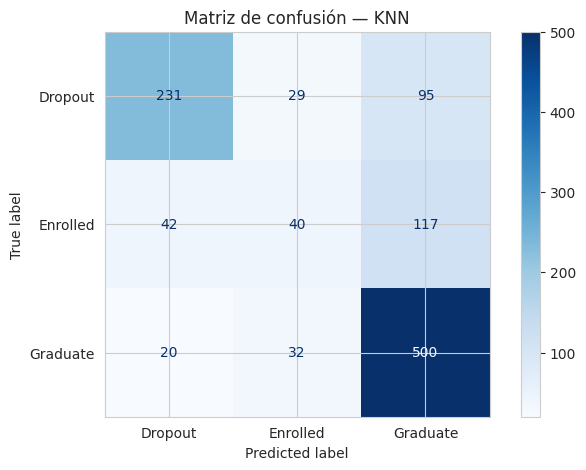

In [18]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión — KNN")
plt.show()


In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)

print("=== Naive Bayes — Reporte de clasificación ===")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))


=== Naive Bayes — Reporte de clasificación ===
              precision    recall  f1-score   support

     Dropout       0.72      0.64      0.68       355
    Enrolled       0.29      0.21      0.24       199
    Graduate       0.71      0.83      0.77       552

    accuracy                           0.66      1106
   macro avg       0.57      0.56      0.56      1106
weighted avg       0.64      0.66      0.64      1106



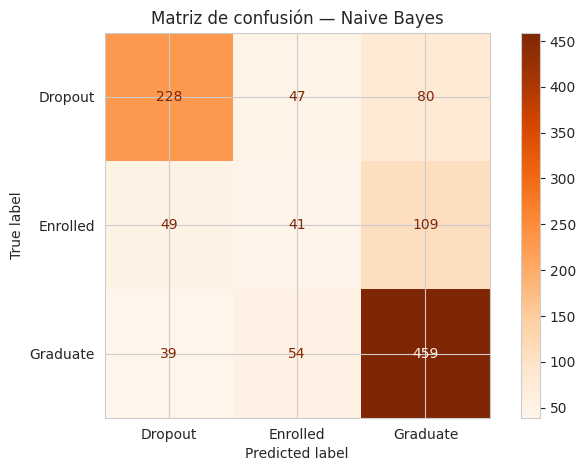

In [20]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)
disp.plot(cmap="Oranges")
plt.title("Matriz de confusión — Naive Bayes")
plt.show()


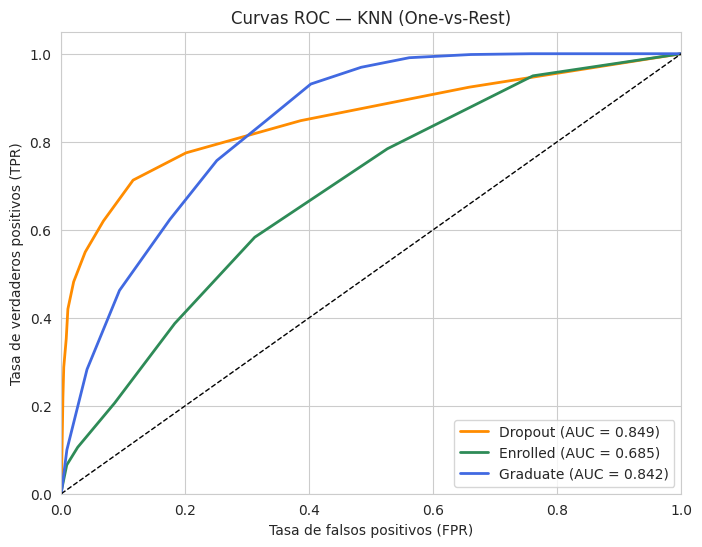

KNN — AUC macro: 0.7921 | AUC weighted: 0.8160


In [21]:
classes = le.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

def plot_roc(y_true_bin, y_proba, model_name, colors):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{classes[i]} (AUC = {roc_auc[i]:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Tasa de falsos positivos (FPR)")
    plt.ylabel("Tasa de verdaderos positivos (TPR)")
    plt.title(f"Curvas ROC — {model_name} (One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.show()

    macro_auc = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    weighted_auc = roc_auc_score(y_true_bin, y_proba, average="weighted", multi_class="ovr")
    print(f"{model_name} — AUC macro: {macro_auc:.4f} | AUC weighted: {weighted_auc:.4f}")
    return macro_auc, weighted_auc

colors = ["darkorange", "seagreen", "royalblue"]
knn_macro_auc, knn_weighted_auc = plot_roc(y_test_bin, y_proba_knn, "KNN", colors)


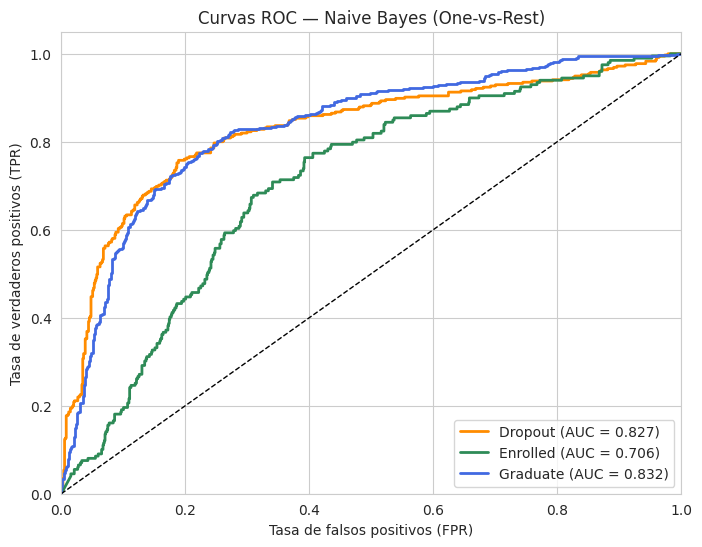

Naive Bayes — AUC macro: 0.7887 | AUC weighted: 0.8080


In [22]:
nb_macro_auc, nb_weighted_auc = plot_roc(y_test_bin, y_proba_nb, "Naive Bayes", colors)


In [23]:
results = pd.DataFrame({
    "Modelo": ["KNN", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
    ],
    "F1-macro": [
        f1_score(y_test, y_pred_knn, average="macro"),
        f1_score(y_test, y_pred_nb, average="macro"),
    ],
    "AUC-macro": [knn_macro_auc, nb_macro_auc],
    "AUC-weighted": [knn_weighted_auc, nb_weighted_auc],
})

results = results.round(4)
results


,Modelo,Accuracy,F1-macro,AUC-macro,AUC-weighted
0,KNN,0.6971,0.5903,0.7921,0.816
1,Naive Bayes,0.6582,0.5617,0.7887,0.808


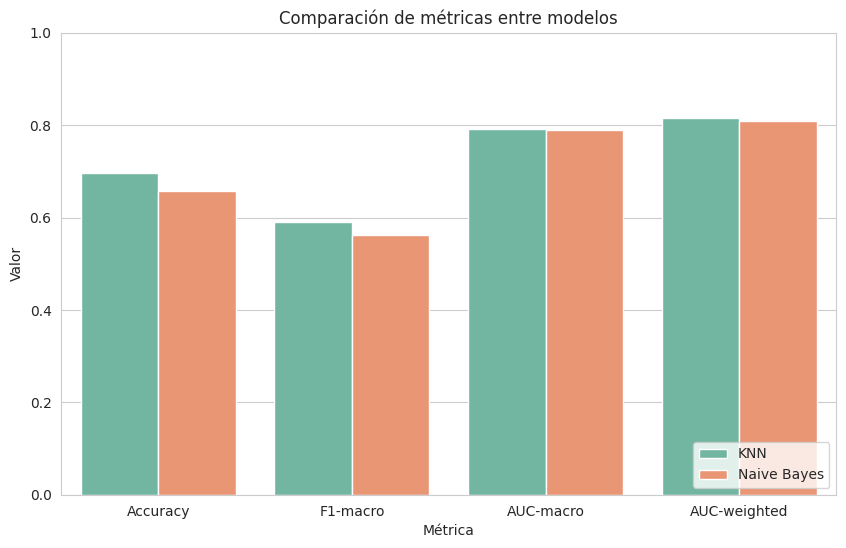

In [24]:
results_melt = results.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melt, x="Métrica", y="Valor", hue="Modelo", palette="Set2")
plt.title("Comparación de métricas entre modelos")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


## Conclusiones

- **Desbalance de clases:** la clase `Graduate` es mayoritaria (~50%), seguida de `Dropout`
  (~32%) y `Enrolled` (~18%). Este desbalance afecta especialmente la detección de la clase
  `Enrolled`, que suele ser la más difícil de predecir para ambos modelos.

- **Variables más relevantes:** las variables académicas relacionadas con el desempeño en el
  primer y segundo semestre (materias aprobadas, notas promedio) muestran la relación más
  fuerte con el resultado final, seguidas por variables socioeconómicas como estar al día con
  la matrícula (`Tuition fees up to date`) y ser deudor (`Debtor`).

- **KNN vs Naive Bayes:**
  - KNN, al basarse en distancias, se beneficia del escalado de variables y tiende a capturar
    mejor relaciones no lineales, pero es más sensible al desbalance de clases y a la elección
    de `k`.
  - Naive Bayes asume independencia entre variables (una simplificación fuerte para este
    dataset, donde muchas variables académicas están correlacionadas), pero es rápido y
    ofrece una base de comparación razonable.
  - En términos de **AUC-ROC**, ambos modelos discriminan razonablemente bien la clase
    `Graduate` (la más numerosa y con patrones más claros), mientras que `Enrolled` es la
    clase con menor AUC en ambos casos, reflejando su mayor ambigüedad respecto a las otras
    dos categorías.

- **Recomendaciones para mejorar el modelo:**
  1. Probar técnicas de balanceo de clases (SMOTE, undersampling) o ajuste de pesos (`class_weight`).
  2. Explorar modelos adicionales (Regresión Logística, Random Forest, Gradient Boosting) que
     suelen tener mejor desempeño en este tipo de datasets tabulares.
  3. Realizar selección/ingeniería de variables (por ejemplo, tasa de aprobación = aprobadas/matriculadas)
     para reducir ruido y mejorar la separación entre clases.
  4. Evaluar el impacto de variables socioeconómicas del entorno (desempleo, inflación, PIB)
     de forma más granular, ya que actualmente aportan señal moderada.

En resumen, el desempeño académico temprano del estudiante es el predictor más fuerte de si
abandonará, continuará matriculado o se graduará, y un enfoque de intervención temprana
basado en estas variables podría ser más efectivo que basarse únicamente en factores
demográficos o socioeconómicos.
